# Análisis Exploratorio de Datos (EDA) — Chest X-Ray Pneumonia

**Proyecto Final: Redes Neuronales y Deep Learning**

**Dataset:** Chest X-Ray Images (Pneumonia)
**Kaggle handle:** `paultimothymooney/chest-xray-pneumonia`

Este notebook realiza el análisis exploratorio previo que exige la guía del proyecto, antes de entrenar los modelos CNN Baseline y Transfer Learning. Se analiza: estructura de carpetas, distribución de clases, dimensiones de imagen, e intensidad de píxeles.

## 1. Configuración e importación de librerías

In [1]:
import importlib.util
import subprocess
import sys
from collections import Counter
from pathlib import Path

def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        package_name = pip_name or import_name
        print(f"Instalando dependencia faltante: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

ensure_package("kagglehub")
ensure_package("PIL", "Pillow")

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


## 2. Descarga y detección del dataset

Se descarga el dataset y se localiza la carpeta raíz que contiene `train`, `val` y `test`, igual que en los notebooks de modelado, para mantener consistencia entre el EDA y el entrenamiento.

In [2]:
import os

DATASET_HANDLE = "paultimothymooney/chest-xray-pneumonia"
PROJECT_DIR = Path.cwd()
DOWNLOAD_DIR = PROJECT_DIR / "data" / "raw"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

try:
    downloaded_location = kagglehub.dataset_download(DATASET_HANDLE, output_dir=str(DOWNLOAD_DIR))
except TypeError:
    downloaded_location = kagglehub.dataset_download(DATASET_HANDLE)

downloaded_path = Path(downloaded_location).expanduser().resolve()
print("Ruta devuelta por KaggleHub:", downloaded_path)


def find_dataset_root(search_root):
    """Busca una carpeta que contenga train, val y test."""
    required = {"train", "val", "test"}
    search_root = Path(search_root).resolve()
    if not search_root.exists():
        return None
    if search_root.is_file():
        search_root = search_root.parent
    for current, dirnames, _ in os.walk(search_root):
        current_path = Path(current)
        children = {d.lower(): current_path / d for d in dirnames}
        if required.issubset(children):
            return current_path, children["train"], children["val"], children["test"]
    return None

result = find_dataset_root(downloaded_path if downloaded_path.is_dir() else downloaded_path.parent)
if result is None:
    result = find_dataset_root(DOWNLOAD_DIR)

assert result is not None, "No se encontró la estructura train/val/test del dataset."
dataset_root, train_dir, val_dir, test_dir = result

print("Dataset root:", dataset_root)
print("Train dir:", train_dir)
print("Val dir:", val_dir)
print("Test dir:", test_dir)


Ruta devuelta por KaggleHub: C:\Users\Usuario\Desktop\Anaconda\ProyectoFinal\mejorado\data\raw
Dataset root: C:\Users\Usuario\Desktop\Anaconda\ProyectoFinal\mejorado\data\raw\chest_xray
Train dir: C:\Users\Usuario\Desktop\Anaconda\ProyectoFinal\mejorado\data\raw\chest_xray\train
Val dir: C:\Users\Usuario\Desktop\Anaconda\ProyectoFinal\mejorado\data\raw\chest_xray\val
Test dir: C:\Users\Usuario\Desktop\Anaconda\ProyectoFinal\mejorado\data\raw\chest_xray\test


## 3. Estructura de carpetas y conteo de imágenes por clase

Se cuenta cuántas imágenes hay en cada split (`train`, `val`, `test`) y en cada clase (`NORMAL`, `PNEUMONIA`). Este es el primer indicador de un posible desbalance de clases, algo común y esperado en datasets médicos.

In [3]:
def count_images(split_dir):
    counts = {}
    for class_dir in sorted(Path(split_dir).iterdir()):
        if class_dir.is_dir():
            n_images = len([
                f for f in class_dir.iterdir()
                if f.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ])
            counts[class_dir.name] = n_images
    return counts

splits = {"train": train_dir, "val": val_dir, "test": test_dir}
all_counts = {split: count_images(path) for split, path in splits.items()}

for split, counts in all_counts.items():
    total = sum(counts.values())
    print(f"\n{split.upper()} (total: {total})")
    for class_name, n in counts.items():
        pct = n / total * 100 if total else 0
        print(f"  {class_name}: {n} ({pct:.1f}%)")



TRAIN (total: 5216)
  NORMAL: 1341 (25.7%)
  PNEUMONIA: 3875 (74.3%)

VAL (total: 16)
  NORMAL: 8 (50.0%)
  PNEUMONIA: 8 (50.0%)

TEST (total: 624)
  NORMAL: 234 (37.5%)
  PNEUMONIA: 390 (62.5%)


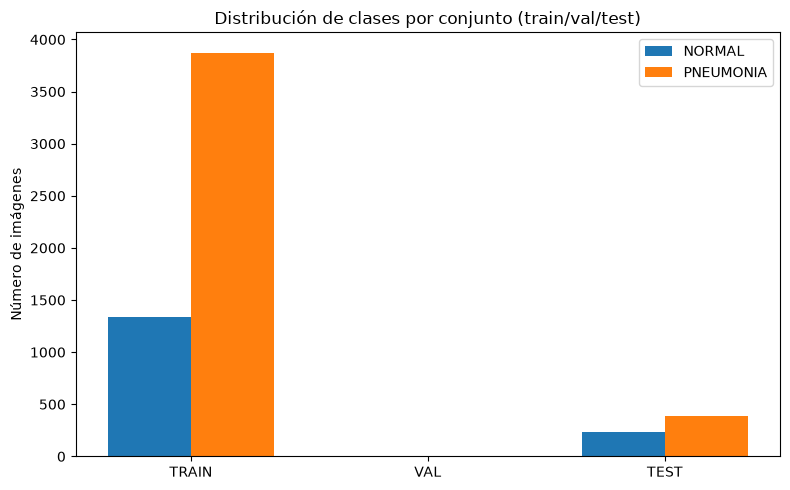

In [4]:
# Gráfico de barras: distribución de clases por split
classes = sorted({c for counts in all_counts.values() for c in counts})
x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
for i, class_name in enumerate(classes):
    values = [all_counts[split].get(class_name, 0) for split in splits]
    ax.bar(x + (i - 0.5) * width, values, width, label=class_name)

ax.set_xticks(x)
ax.set_xticklabels([s.upper() for s in splits])
ax.set_ylabel("Número de imágenes")
ax.set_title("Distribución de clases por conjunto (train/val/test)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Observación clave: desbalance de clases y tamaño del conjunto de validación

El dataset original suele tener: (a) más imágenes `PNEUMONIA` que `NORMAL` en `train` (desbalance ~3:1), y (b) una carpeta `val` muy pequeña (16 imágenes). Esto justifica la decisión —tomada en ambos notebooks de modelado— de re-particionar el conjunto de entrenamiento (80/20 estratificado) para obtener una validación más representativa, en lugar de usar la carpeta `val` oficial tal cual.

## 5. Muestra visual de imágenes por clase

Se muestran ejemplos aleatorios de cada clase para inspeccionar visualmente diferencias de contraste, encuadre y calidad entre radiografías `NORMAL` y `PNEUMONIA`.

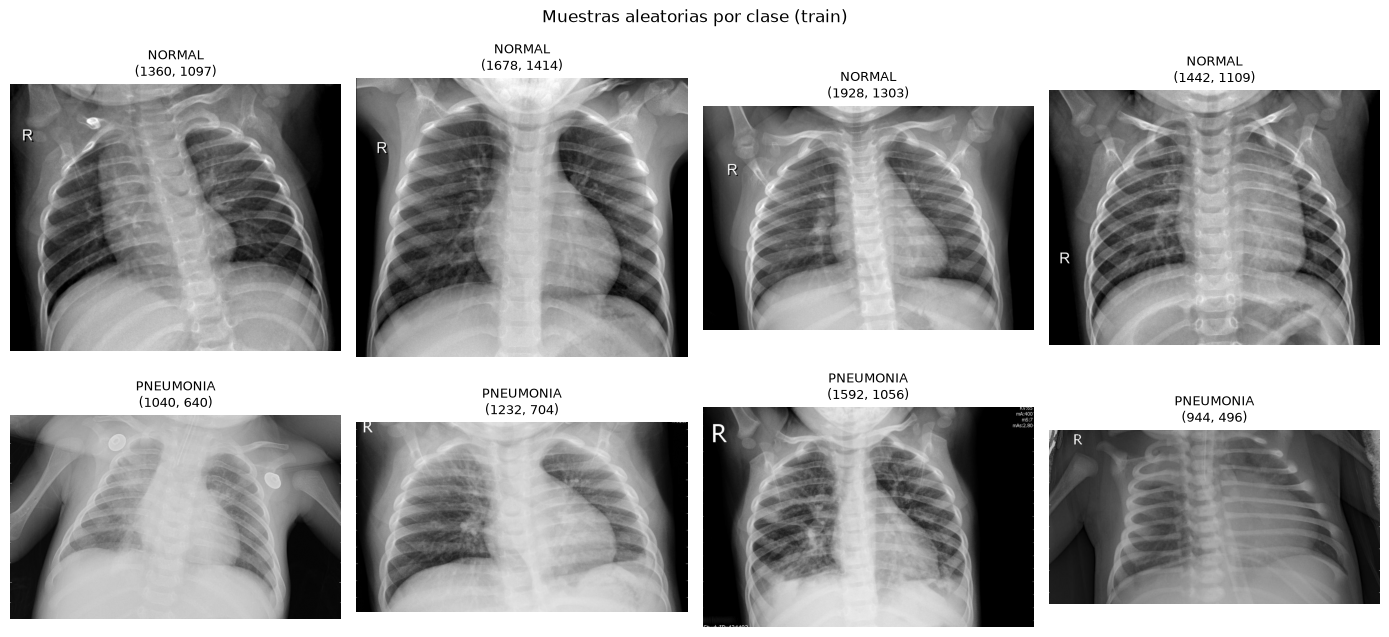

In [5]:
import random
random.seed(42)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row, class_name in enumerate(classes):
    class_dir = train_dir / class_name
    image_files = [f for f in class_dir.iterdir() if f.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    sample_files = random.sample(image_files, 4)

    for col, img_path in enumerate(sample_files):
        with Image.open(img_path) as img:
            axes[row, col].imshow(img.convert("L"), cmap="gray")
        axes[row, col].set_title(f"{class_name}\n{img.size}", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Muestras aleatorias por clase (train)")
plt.tight_layout()
plt.show()


## 6. Distribución de dimensiones de imagen

Las radiografías de este dataset provienen de distintos equipos y no tienen un tamaño uniforme. Se analiza la distribución de ancho y alto sobre una muestra del conjunto de entrenamiento, lo cual justifica el `Resize` aplicado en los pipelines de modelado (128×128 en el baseline, 224×224 en transfer learning por requisito de ResNet18).

In [6]:
SAMPLE_SIZE_PER_CLASS = 150

widths, heights, aspect_ratios = [], [], []

for class_name in classes:
    class_dir = train_dir / class_name
    image_files = [f for f in class_dir.iterdir() if f.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    sample_files = random.sample(image_files, min(SAMPLE_SIZE_PER_CLASS, len(image_files)))

    for img_path in sample_files:
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)

print(f"Muestra analizada: {len(widths)} imágenes")
print(f"Ancho -> min: {min(widths)}, max: {max(widths)}, media: {np.mean(widths):.0f}")
print(f"Alto  -> min: {min(heights)}, max: {max(heights)}, media: {np.mean(heights):.0f}")
print(f"Aspect ratio (w/h) -> min: {min(aspect_ratios):.2f}, max: {max(aspect_ratios):.2f}, "
      f"media: {np.mean(aspect_ratios):.2f}")


Muestra analizada: 300 imágenes
Ancho -> min: 508, max: 2844, media: 1414
Alto  -> min: 218, max: 2628, media: 1080
Aspect ratio (w/h) -> min: 0.92, max: 2.33, media: 1.38


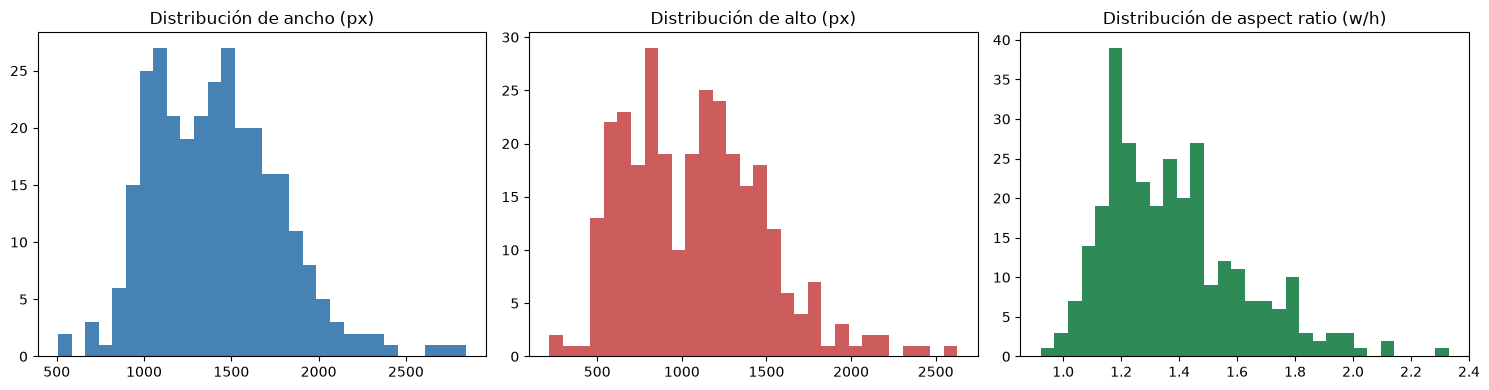

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths, bins=30, color="steelblue")
axes[0].set_title("Distribución de ancho (px)")

axes[1].hist(heights, bins=30, color="indianred")
axes[1].set_title("Distribución de alto (px)")

axes[2].hist(aspect_ratios, bins=30, color="seagreen")
axes[2].set_title("Distribución de aspect ratio (w/h)")

plt.tight_layout()
plt.show()


## 7. Distribución de intensidad de píxeles por clase

Se compara el histograma de intensidad de píxeles (escala de grises, 0-255) entre las clases `NORMAL` y `PNEUMONIA`. Radiografías con neumonía suelen presentar zonas de mayor opacidad (infiltrados/consolidaciones), lo que puede reflejarse en la distribución de intensidades.

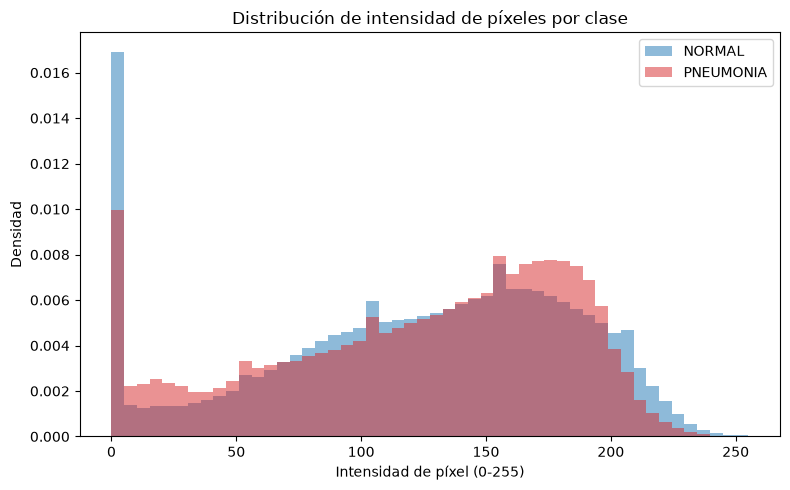

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

for class_name, color in zip(classes, ["tab:blue", "tab:red"]):
    class_dir = train_dir / class_name
    image_files = [f for f in class_dir.iterdir() if f.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    sample_files = random.sample(image_files, min(SAMPLE_SIZE_PER_CLASS, len(image_files)))

    pixel_values = []
    for img_path in sample_files:
        with Image.open(img_path) as img:
            img_gray = img.convert("L").resize((128, 128))
            pixel_values.extend(np.array(img_gray).flatten())

    ax.hist(pixel_values, bins=50, alpha=0.5, label=class_name, color=color, density=True)

ax.set_xlabel("Intensidad de píxel (0-255)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de intensidad de píxeles por clase")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Conclusiones del EDA

- **Desbalance de clases:** el conjunto de entrenamiento tiene notablemente más imágenes `PNEUMONIA` que `NORMAL`. Esto explica por qué, en el notebook baseline, el modelo tiende inicialmente a favorecer la clase mayoritaria (mayor recall en `PNEUMONIA` que en `NORMAL`).
- **Validación oficial insuficiente:** la carpeta `val` original tiene muy pocas imágenes, por lo que ambos notebooks de modelado re-particionan el conjunto `train` (80/20 estratificado) para validar de forma más confiable.
- **Tamaños heterogéneos:** las radiografías varían en resolución y aspect ratio, lo que justifica el `Resize` fijo aplicado antes de entrenar (128×128 en el CNN baseline, 224×224 en transfer learning).
- **Intensidad de píxeles:** existen diferencias visibles en la distribución de intensidad entre clases, lo cual es consistente con la presencia de opacidades/infiltrados en las radiografías con neumonía, y respalda que el problema es aprendible a partir de las imágenes.
- **Recomendación aplicada:** dado el desbalance y el tamaño limitado del dataset, se aplican Data Augmentation (flip horizontal + rotación), Dropout, Batch Normalization y Early Stopping en los notebooks de modelado, tal como recomienda la guía del proyecto.